In [2]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Cargamos la base de datos
data = pd.read_csv('Plazas_Sin_Nulos.csv')

In [4]:
# Revisamos cuántas filas y columnas tiene la base

data.shape

(303, 16)

In [5]:
# Revisamos los nombres de las columnas

data.columns

Index(['Fecha Origen', 'Nombre', 'Producto', 'Asesor', 'Origen', 'Seguimiento',
       'Cita efetiva ', 'PDM', 'SDC', 'Estatus',
       '¿Por que no hay seguimiento?', '¿Por que no ha visitado la agencia?',
       '¿Por que no hubo prueba de manejo ?',
       '¿Por que no hubo solicitud de credito?',
       '¿Por que no se ha formalizado la compra?', 'Comentarios adicionales'],
      dtype='str')

In [6]:
# Revisamos el tipo de dato de cada variable

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Fecha Origen                              303 non-null    str  
 1   Nombre                                    303 non-null    str  
 2   Producto                                  303 non-null    str  
 3   Asesor                                    303 non-null    str  
 4   Origen                                    303 non-null    str  
 5   Seguimiento                               303 non-null    str  
 6   Cita efetiva                              303 non-null    str  
 7   PDM                                       303 non-null    str  
 8   SDC                                       303 non-null    str  
 9   Estatus                                   303 non-null    str  
 10  ¿Por que no hay seguimiento?              303 non-null    str  
 11  ¿Por

In [7]:
# Revisamos los valores diferentes de las variables
# relacionadas con seguimiento y venta

columnas_revision = [
    'Seguimiento',
    'Cita efetiva ',
    'PDM',
    'SDC'
]

for columna in columnas_revision:

    print("\nVariable:", columna)

    print(
        data[columna].value_counts(
            dropna=False
        )
    )


Variable: Seguimiento
Seguimiento
1.0                          201
0.0                           96
Seguimiento no registrado      6
Name: count, dtype: int64

Variable: Cita efetiva 
Cita efetiva 
0.0                   268
1.0                    26
Cita no registrada      9
Name: count, dtype: int64

Variable: PDM
PDM
0.0                  271
1.0                   22
PDM no registrado     10
Name: count, dtype: int64

Variable: SDC
SDC
0.0                  284
SDC no registrado     10
1.0                    9
Name: count, dtype: int64


In [8]:
# Creamos una copia numérica solamente para análisis

datos_numericos = data[
    columnas_revision
].copy()

for columna in columnas_revision:

    datos_numericos[columna] = pd.to_numeric(
        datos_numericos[columna],
        errors='coerce'
    )

datos_numericos.head()

,Seguimiento,Cita efetiva,PDM,SDC
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


In [9]:
# Revisamos un resumen de las variables numéricas

datos_numericos.describe()

,Seguimiento,Cita efetiva,PDM,SDC
count,297.000000,294.000000,293.000000,293.000000
mean,0.676768,0.088435,0.075085,0.030717
std,0.468500,0.284411,0.263980,0.172844
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_1157/837204549.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


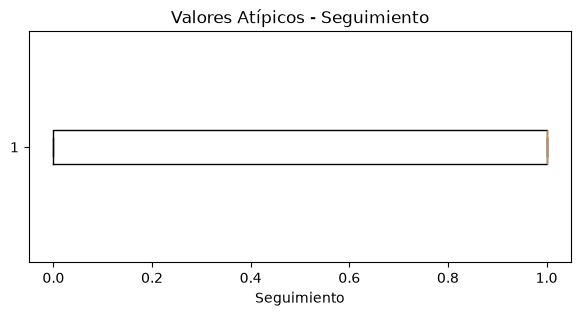

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_1157/837204549.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


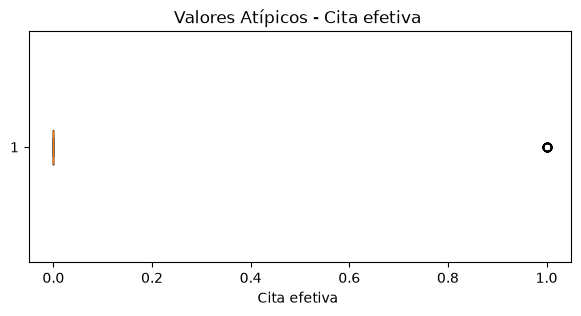

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_1157/837204549.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


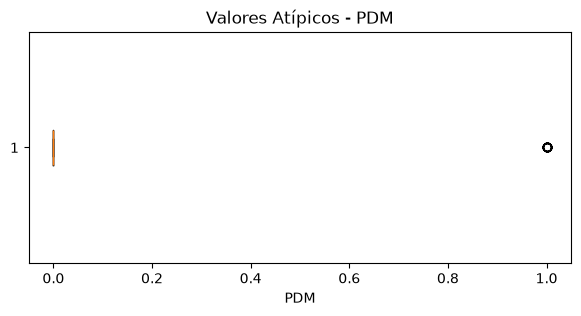

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_1157/837204549.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


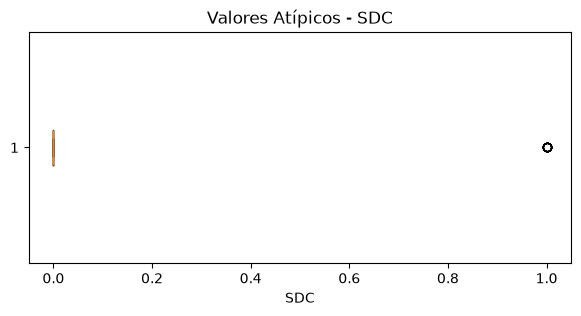

In [10]:
# Diagramas de caja de cada variable

for columna in columnas_revision:

    plt.figure(figsize=(7,3))

    plt.boxplot(
        datos_numericos[columna].dropna(),
        vert=False
    )

    plt.title(
        "Valores Atípicos - " + columna
    )

    plt.xlabel(columna)

    plt.show()

# Método 1: Desviación Estándar

El método de Desviación Estándar permite identificar datos que se encuentran demasiado alejados del promedio.

Sin embargo, antes de eliminar cualquier valor es necesario revisar el significado de cada variable.

En esta base, Seguimiento, Cita efectiva, PDM y SDC son variables binarias de 0 y 1, por lo que los valores 1 representan respuestas válidas y no necesariamente valores atípicos.

In [11]:
# Calculamos los límites utilizando
# media ± 3 desviaciones estándar

y = datos_numericos

Limite_Superior = y.mean() + 3 * y.std()

Limite_Inferior = y.mean() - 3 * y.std()

print("Límite Superior:")
print(Limite_Superior)

print("\nLímite Inferior:")
print(Limite_Inferior)

Límite Superior:
Seguimiento      2.082268
Cita efetiva     0.941669
PDM              0.867025
SDC              0.549250
dtype: float64

Límite Inferior:
Seguimiento     -0.728732
Cita efetiva    -0.764798
PDM             -0.716854
SDC             -0.487816
dtype: float64


In [12]:
# Aplicamos los límites calculados

data_std = datos_numericos[
    (y <= Limite_Superior) &
    (y >= Limite_Inferior)
]

data_std.head()

,Seguimiento,Cita efetiva,PDM,SDC
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


In [13]:
# Contamos solamente los valores detectados
# como posibles outliers por el método

outliers_std = (
    data_std.isnull().sum()
    -
    datos_numericos.isnull().sum()
)

print("Posibles valores atípicos según Desviación Estándar:")

outliers_std

Posibles valores atípicos según Desviación Estándar:


Seguimiento       0
Cita efetiva     26
PDM              22
SDC               9
dtype: int64

In [14]:
# Debido a que las variables son binarias,
# no eliminamos los valores 1

Datos_limpios_std = data.copy()

Datos_limpios_std.head()

,Fecha Origen,Nombre,Producto,Asesor,Origen,Seguimiento,Cita efetiva,PDM,SDC,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,Comentarios adicionales
0,2025-05-06 18:30:00,Alejandro Fernandez,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
1,2025-05-06 18:00:00,David Israel,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,1.0,0.0,0.0,0.0,Finalizado,Si hay seguimiento,Dejo de contestar,Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
2,2025-05-06 13:50:00,Rosendo Ceron,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
3,2025-05-06 13:47:00,Fausto Ochoa Martinez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
4,2025-05-06 13:43:00,Brigida Lara Perez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional


In [15]:
# Guardamos el archivo correspondiente
# al método de Desviación Estándar

Datos_limpios_std.to_csv(
    "Datos_Desviacion_Estandar.csv",
    index=False
)

# Método 2: Rango Intercuartílico (IQR)

El método IQR utiliza el primer cuartil (Q1), el tercer cuartil (Q3) y el rango intercuartílico para identificar valores que se encuentran alejados de la mayoría.

Al igual que con la Desviación Estándar, los resultados deben interpretarse considerando el tipo de variable.

In [16]:
# Calculamos Q1 y Q3

y = datos_numericos

percentile25 = y.quantile(0.25)

percentile75 = y.quantile(0.75)

print("Q1:")
print(percentile25)

print("\nQ3:")
print(percentile75)

Q1:
Seguimiento      0.0
Cita efetiva     0.0
PDM              0.0
SDC              0.0
Name: 0.25, dtype: float64

Q3:
Seguimiento      1.0
Cita efetiva     0.0
PDM              0.0
SDC              0.0
Name: 0.75, dtype: float64


In [17]:
# Calculamos el Rango Intercuartílico

iqr = percentile75 - percentile25

iqr

Seguimiento      1.0
Cita efetiva     0.0
PDM              0.0
SDC              0.0
dtype: float64

In [18]:
# Calculamos los límites del método IQR

Limite_Superior_iqr = (
    percentile75 + 1.5 * iqr
)

Limite_Inferior_iqr = (
    percentile25 - 1.5 * iqr
)

print("Límite Superior:")
print(Limite_Superior_iqr)

print("\nLímite Inferior:")
print(Limite_Inferior_iqr)

Límite Superior:
Seguimiento      2.5
Cita efetiva     0.0
PDM              0.0
SDC              0.0
dtype: float64

Límite Inferior:
Seguimiento     -1.5
Cita efetiva     0.0
PDM              0.0
SDC              0.0
dtype: float64


In [19]:
# Aplicamos los límites de IQR

data_iqr = datos_numericos[
    (y <= Limite_Superior_iqr) &
    (y >= Limite_Inferior_iqr)
]

data_iqr.head()

,Seguimiento,Cita efetiva,PDM,SDC
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


In [20]:
# Contamos solamente los valores identificados
# como posibles outliers

outliers_iqr = (
    data_iqr.isnull().sum()
    -
    datos_numericos.isnull().sum()
)

print("Posibles valores atípicos según IQR:")

outliers_iqr

Posibles valores atípicos según IQR:


Seguimiento       0
Cita efetiva     26
PDM              22
SDC               9
dtype: int64

In [21]:
# Debido a que las variables son binarias,
# conservamos los registros originales

Datos_limpios_iqr = data.copy()

Datos_limpios_iqr.head()

,Fecha Origen,Nombre,Producto,Asesor,Origen,Seguimiento,Cita efetiva,PDM,SDC,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,Comentarios adicionales
0,2025-05-06 18:30:00,Alejandro Fernandez,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
1,2025-05-06 18:00:00,David Israel,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,1.0,0.0,0.0,0.0,Finalizado,Si hay seguimiento,Dejo de contestar,Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
2,2025-05-06 13:50:00,Rosendo Ceron,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
3,2025-05-06 13:47:00,Fausto Ochoa Martinez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional
4,2025-05-06 13:43:00,Brigida Lara Perez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",Sin informacion registrada,Sin informacion registrada,Sin informacion registrada,Sin comentario adicional


In [22]:
# Guardamos el archivo correspondiente al método IQR

Datos_limpios_iqr.to_csv(
    "Datos_IQR.csv",
    index=False
)

## Conclusión

En esta base de datos se analizaron las variables Seguimiento, Cita efectiva, PDM y SDC.

Estas variables contienen valores 0 y 1, además de algunos registros sin información. Después de convertir temporalmente los valores 0 y 1 a formato numérico, se aplicaron los métodos de Desviación Estándar y Rango Intercuartílico.

Ambos métodos identificaron algunos valores 1 como posibles valores atípicos, principalmente en Cita efectiva, PDM y SDC. Sin embargo, estos valores no fueron eliminados porque las variables son binarias y los valores 0 y 1 representan categorías válidas.

Por lo tanto, se decidió conservar los registros originales para evitar eliminar información correcta.